# 02 — From our raw TMDB data to a proposed knowledge graph

Notebook 01 teaches the reference's prepared tables. This lesson starts with
our **two raw TMDB 5000 CSV files** in data/raw and shows how nested fields
would become similar tables and then RDF resources.

**Bounded sample:** read at most 100 rows from each file. We do not load, count,
hash, or scan the complete files. Display small previews rather than full cast
or crew lists. All statistics refer to the selected rows, not the entire dataset.
The first rows are a convenience sample, not a random or representative sample.

Read each explanation before running its cell. We build only in-memory examples.
The ontology, production exporter, and RDF transformation come later.

Route: raw structure → join IDs → nested lists → one movie → classes and
instances → credit roles → quality and constraints → optional additions →
planned CSV layout → final decisions.

## 1. Read a small sample

Movie details and credits are separate. Join movies.id to credits.movie_id.
A title is a label, not a safe join key. We read IDs as strings, which also
preserves language/country codes and avoids interpreting the country code NA
as a missing value.

Both files have their own row order. We measure their sampled overlap; if an
ID is absent from sampled credits, we do not claim the full file lacks credits.
Increase SAMPLE_ROWS manually if you want a larger bounded view.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

SAMPLE_ROWS = 100
if not isinstance(SAMPLE_ROWS, int) or not 1 <= SAMPLE_ROWS <= 500:
    raise ValueError('Choose an explicit small sample size between 1 and 500.')
candidates = [Path.cwd(), *Path.cwd().parents]
PROJECT = next((q for p in candidates for q in (p, p / 'semantic-web')
                if (q / 'data/raw/tmdb_5000_movies.csv').is_file()), None)
if PROJECT is None:
    raise FileNotFoundError('Cannot find data/raw; keep this notebook inside semantic-web.')
RAW = PROJECT / 'data/raw'
movies = pd.read_csv(RAW / 'tmdb_5000_movies.csv', nrows=SAMPLE_ROWS,
                     dtype=str, keep_default_na=False)
credits = pd.read_csv(RAW / 'tmdb_5000_credits.csv', nrows=SAMPLE_ROWS,
                      dtype=str, keep_default_na=False)
pd.set_option('display.max_colwidth', 65)
pd.set_option('display.max_columns', 10)
pd.set_option('display.max_rows', 45)
plt.rcParams.update({'figure.figsize': (9, 4), 'axes.spines.top': False,
                     'axes.spines.right': False})
print('Source:', RAW)
print('Sampled rows:', {'movies': len(movies), 'credits': len(credits)})
print('These are sample counts, not full-file counts.')

Source: c:\Users\admin\Programming\semanticweb\semantic-web\data\raw
Sampled rows: {'movies': 100, 'credits': 100}
These are sample counts, not full-file counts.


## 2. What the raw rows contain

The movie file mixes ordinary scalar columns with **JSON lists stored as CSV
strings**. The credits file contains a movie ID/title and two nested lists.
Nested JSON is structured data, even though pandas initially sees a string.

We first summarize columns and small examples. Long nested strings are
abbreviated; we will inspect their internal fields separately.

In [2]:
def overview(df):
    return pd.DataFrame({
        'field': df.columns,
        'empty cells in sample': [int(df[c].str.strip().eq('').sum()) for c in df.columns],
        'example (abbreviated)': [df[c].iloc[0][:100] for c in df.columns]})
display(Markdown('**Movie fields**')); display(overview(movies))
display(Markdown('**Credit fields**')); display(overview(credits))
display(movies[['id', 'title', 'release_date', 'runtime', 'vote_average', 'vote_count']].head(3))
display(credits[['movie_id', 'title']].head(3))

**Movie fields**

,field,empty cells in sample,example (abbreviated)
0,budget,0,237000000
1,genres,0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""name"": ""Adventure""..."
2,homepage,17,http://www.avatarmovie.com/
3,id,0,19995
4,keywords,0,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"": 2964, ""name"": ..."
5,original_language,0,en
6,original_title,0,Avatar
7,overview,0,"In the 22nd century, a paraplegic Marine is dispatched to the..."
8,popularity,0,150.437577
9,production_companies,0,"[{""name"": ""Ingenious Film Partners"", ""id"": 289}, {""name"": ""Tw..."


**Credit fields**

,field,empty cells in sample,example (abbreviated)
0,movie_id,0,19995
1,title,0,Avatar
2,cast,0,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""credit_id"": ""56..."
3,crew,0,"[{""credit_id"": ""52fe48009251416c750aca23"", ""department"": ""Edi..."


,id,title,release_date,runtime,vote_average,vote_count
0,19995,Avatar,2009-12-10,162,7.2,11800
1,285,Pirates of the Caribbean: At World's End,2007-05-19,169,6.9,4500
2,206647,Spectre,2015-10-26,148,6.3,4466


,movie_id,title
0,19995,Avatar
1,285,Pirates of the Caribbean: At World's End
2,206647,Spectre


### Every movie field: what might it become?

| Raw field | Meaning | Proposed treatment |
|---|---|---|
| id | TMDB movie ID | Key used to build a Movie URI |
| title | Display title | schema:name literal |
| original_title | Original title | Optional kg:originalTitle literal |
| overview | Synopsis | schema:abstract literal; do not extract claims automatically |
| tagline | Short promotional text | Optional kg:tagline literal |
| homepage | Source homepage URL | Optional resource link; not an identity assertion |
| original_language | Original-language code | kg:originalLanguage → Language instance |
| release_date | Source release date | schema:datePublished, xsd:date |
| runtime | Minutes | schema:duration, xsd:duration |
| vote_average | Average score | ratingValue on an AggregateRating node |
| vote_count | Vote total | ratingCount on the same node |
| popularity | Source popularity metric | Optional decimal; snapshot-specific, not quality |
| budget | Reported budget | Optional kg:budgetUSD; zero needs review |
| revenue | Reported revenue | Optional kg:revenueUSD; zero needs review |
| status | Release-status label | Optional kg:status literal initially |
| genres | List of genre objects | Genre instances + movie–genre links |
| keywords | List of descriptive terms | Optional Keyword/DefinedTerm instances + movie–keyword links |
| production_companies | List of company objects | Organization instances + movie–company links |
| production_countries | List of country objects | Country instances + movie–country links |
| spoken_languages | List of language objects | Language instances + movie–language links |

The currency convention for budget/revenue should be documented and checked
against dataset provenance before financial claims. These CSVs do not provide
currency, exchange-rate, or observation-time columns.

The credit file's title is a duplicate label for inspection. Its movie_id is
the join key. Cast and crew fields will be unpacked below.

In [3]:
print('Unique sampled movie IDs:', movies.id.is_unique)
print('Unique sampled credit movie IDs:', credits.movie_id.is_unique)
print('Empty keys:', {'movies': int(movies.id.eq('').sum()),
                      'credits': int(credits.movie_id.eq('').sum())})
missing_sample_credits = sorted(set(movies.id) - set(credits.movie_id))
unused_sample_credits = sorted(set(credits.movie_id) - set(movies.id))
print('Movie IDs absent from sampled credits:', missing_sample_credits[:10],
      'count:', len(missing_sample_credits))
print('Credit IDs outside sampled movies:', unused_sample_credits[:10],
      'count:', len(unused_sample_credits))
assert movies.id.is_unique and credits.movie_id.is_unique, 'Resolve duplicate keys before joining.'
joined = movies[['id', 'title']].merge(credits[['movie_id', 'title']],
                                      left_on='id', right_on='movie_id', how='left',
                                      suffixes=('_movie', '_credit'), validate='one_to_one', indicator=True)
display(joined.loc[joined['_merge'].eq('both') &
                   joined.title_movie.ne(joined.title_credit)].head(5))
print('Movie labels duplicated in sample:', int(movies.title.duplicated().sum()))

Unique sampled movie IDs: True
Unique sampled credit movie IDs: True
Empty keys: {'movies': 0, 'credits': 0}
Movie IDs absent from sampled credits: [] count: 0
Credit IDs outside sampled movies: [] count: 0


,id,title_movie,movie_id,title_credit,_merge


Movie labels duplicated in sample: 0


**Decision:** movie IDs establish identity; titles remain labels. Even if
sampled titles are all unique, a future dataset may contain remakes or same-name
films. Duplicate keys or conflicting names deserve review before normalization.

Two source limitations matter for matching the reference:

- These raw files have no imdb_id column. Link later using TMDB IDs and review
  evidence, or enrich from an external source; do not fabricate IMDb IDs.
- Company objects here do not supply origin_country. Movie production countries
  do not establish each company's own country. The reference's company-country
  inference needs additional company data before we can reproduce it.

## 3. Parse the nested JSON, then expose the fields inside it

Use json.loads, not eval. Each JSON object describes an entity or participation.
An empty list means no entries were recorded in that cell; it does not prove
the real-world film has no genres, cast, or production companies.

We parse only sampled rows, with a useful error naming the movie and column
if the content is malformed. Flattening creates an in-memory preview table.

In [4]:
MOVIE_LISTS = ['genres', 'keywords', 'production_companies', 'production_countries', 'spoken_languages']
def parse_list(value, label):
    if not value.strip():
        return []
    try:
        result = json.loads(value)
    except json.JSONDecodeError as exc:
        raise ValueError(f'Invalid JSON in {label}') from exc
    if not isinstance(result, list) or any(not isinstance(x, dict) for x in result):
        raise ValueError(f'Expected a list of objects in {label}')
    return result

parsed_movies = movies.copy()
parsed_credits = credits.copy()
for col in MOVIE_LISTS:
    parsed_movies[col] = [parse_list(value, f'movie {mid}: {col}')
                          for mid, value in zip(movies.id, movies[col])]
for col in ['cast', 'crew']:
    parsed_credits[col] = [parse_list(value, f'movie {mid}: {col}')
                           for mid, value in zip(credits.movie_id, credits[col])]

def flatten(df, key, col):
    records = []
    for mid, items in zip(df[key], df[col]):
        for item in items:
            records.append({'movie_id': mid, **item})
    return pd.DataFrame(records)
flat = {c: flatten(parsed_movies, 'id', c) for c in MOVIE_LISTS}
flat.update({c: flatten(parsed_credits, 'movie_id', c) for c in ['cast', 'crew']})
display(pd.DataFrame([{'nested column': c, 'sample entries': len(d),
                       'internal fields': ', '.join(d.columns.drop('movie_id', errors='ignore'))}
                      for c, d in flat.items()]))
for col, df in flat.items():
    display(Markdown(f'**Inside {col}: two entries only**'))
    display(df.head(2))

,nested column,sample entries,internal fields
0,genres,330,"id, name"
1,keywords,1049,"id, name"
2,production_companies,381,"name, id"
3,production_countries,150,"iso_3166_1, name"
4,spoken_languages,170,"iso_639_1, name"
5,cast,4888,"cast_id, character, credit_id, gender, id, name, order"
6,crew,6721,"credit_id, department, gender, id, job, name"


**Inside genres: two entries only**

,movie_id,id,name
0,19995,28,Action
1,19995,12,Adventure


**Inside keywords: two entries only**

,movie_id,id,name
0,19995,1463,culture clash
1,19995,2964,future


...

,movie_id,iso_639_1,name
0,19995,en,English
1,19995,es,Español


**Inside cast: two entries only**

,movie_id,cast_id,character,credit_id,gender,id,name,order
0,19995,242,Jake Sully,5602a8a7c3a3685532001c9a,2,65731,Sam Worthington,0
1,19995,3,Neytiri,52fe48009251416c750ac9cb,1,8691,Zoe Saldana,1


**Inside crew: two entries only**

,movie_id,credit_id,department,gender,id,job,name
0,19995,52fe48009251416c750aca23,Editing,0,1721,Editor,Stephen E. Rivkin
1,19995,539c47ecc3a36810e3001f87,Art,2,496,Production Design,Rick Carter


### Internal fields: entity facts versus participation facts

| List | Internal fields | Meaning / modeling |
|---|---|---|
| genres, keywords | id, name | A shared term ID and label; term becomes an instance |
| production_companies | id, name | Shared company; Organization instance |
| production_countries | iso_3166_1, name | Country code and label; Country instance |
| spoken_languages | iso_639_1, name | Language code and label; Language instance |
| cast | id, name | Person identity and label |
| cast | character, order | Facts about this acting participation; attach to Role |
| cast | credit_id | Source participation identifier; candidate credit URI key |
| cast | cast_id | Source cast-entry number; do not use as a global Person ID |
| cast, crew | gender | Source-coded person attribute; optional, omit initially |
| crew | id, name | Person identity and label; same ID space as cast |
| crew | credit_id, department, job | Participation identifier, department and job for this movie |

Crew jobs are not global permanent properties of a person. Someone can direct
one film and edit another. A raw gender code is not an OWL class or a reliable
basis for guessing a person's identity; we do not need it for our questions.

## 4. One raw movie, read as a graph

Select the first movie with sampled credits. We display compact scalar facts,
all its small descriptive lists, and five cast/crew entries. Raw lists can be
much longer than the first-ten cast limit used by the reference.

In [5]:
common_ids = set(movies.id) & set(credits.movie_id)
if not common_ids:
    raise ValueError('No overlapping IDs in these bounded samples. Increase SAMPLE_ROWS.')
example_id = next(mid for mid in movies.id if mid in common_ids)
movie = parsed_movies.loc[parsed_movies.id.eq(example_id)].iloc[0]
credit = parsed_credits.loc[parsed_credits.movie_id.eq(example_id)].iloc[0]
display(Markdown(f"### {movie['title']} — movie ID {example_id}"))
display(movie[['id', 'title', 'original_title', 'original_language',
               'release_date', 'runtime', 'vote_average', 'vote_count']].rename('value').to_frame())
for col in MOVIE_LISTS:
    display(Markdown(f'**{col}**')); display(pd.DataFrame(movie[col]).head(8))
print('Recorded cast:', len(credit['cast']), '| Recorded crew:', len(credit['crew']))
display(pd.DataFrame(credit['cast']).head(5))
display(pd.DataFrame(credit['crew']).head(5))

### Avatar — movie ID 19995

,value
id,19995
title,Avatar
original_title,Avatar
original_language,en
release_date,2009-12-10
runtime,162
vote_average,7.2
vote_count,11800


**genres**

,id,name
0,28,Action
1,12,Adventure
2,14,Fantasy
3,878,Science Fiction


**keywords**

...

**spoken_languages**

,iso_639_1,name
0,en,English
1,es,Español


Recorded cast: 83 | Recorded crew: 153


,cast_id,character,credit_id,gender,id,name,order
0,242,Jake Sully,5602a8a7c3a3685532001c9a,2,65731,Sam Worthington,0
1,3,Neytiri,52fe48009251416c750ac9cb,1,8691,Zoe Saldana,1
2,25,Dr. Grace Augustine,52fe48009251416c750aca39,1,10205,Sigourney Weaver,2
3,4,Col. Quaritch,52fe48009251416c750ac9cf,2,32747,Stephen Lang,3
4,5,Trudy Chacon,52fe48009251416c750ac9d3,1,17647,Michelle Rodriguez,4


,credit_id,department,gender,id,job,name
0,52fe48009251416c750aca23,Editing,0,1721,Editor,Stephen E. Rivkin
1,539c47ecc3a36810e3001f87,Art,2,496,Production Design,Rick Carter
2,54491c89c3a3680fb4001cf7,Sound,0,900,Sound Designer,Christopher Boyes
3,54491cb70e0a267480001bd0,Sound,0,900,Supervising Sound Editor,Christopher Boyes
4,539c4a4cc3a36810c9002101,Production,1,1262,Casting,Mali Finn


### Class, instance, property, or literal?

| Source concept | Proposed category | Reason |
|---|---|---|
| Movie | Class schema:Movie | Category of films |
| This movie ID | Instance of Movie | One particular film |
| Person | Class schema:Person | Category shared by actors/directors |
| An actor's id | Instance of Person | Reuse identity across movies and jobs |
| Genre | Class kg:Genre | Category of genre terms |
| Action | Instance of Genre | Named term linked to many movies |
| Company | Class schema:Organization | A company is an entity, not just its name |
| Country / Language | Classes | Codes identify shared instances |
| title, date, runtime | Datatype properties with literals | Describe values rather than new entities |
| movie–actor, movie–genre | Object properties | Connect resources |
| Acting participation | Class schema:Role and a node per retained credit | Connects movie, person, character and order |
| Rating summary | Class schema:AggregateRating and a node per movie snapshot | Groups score and count |

Do not make every genre name a Movie subclass. Do not make every column a
class. “Director” can remain a relationship to Person. One person may both act
and direct. A blank node for Role or Rating is a resource without a global name,
not a null value.

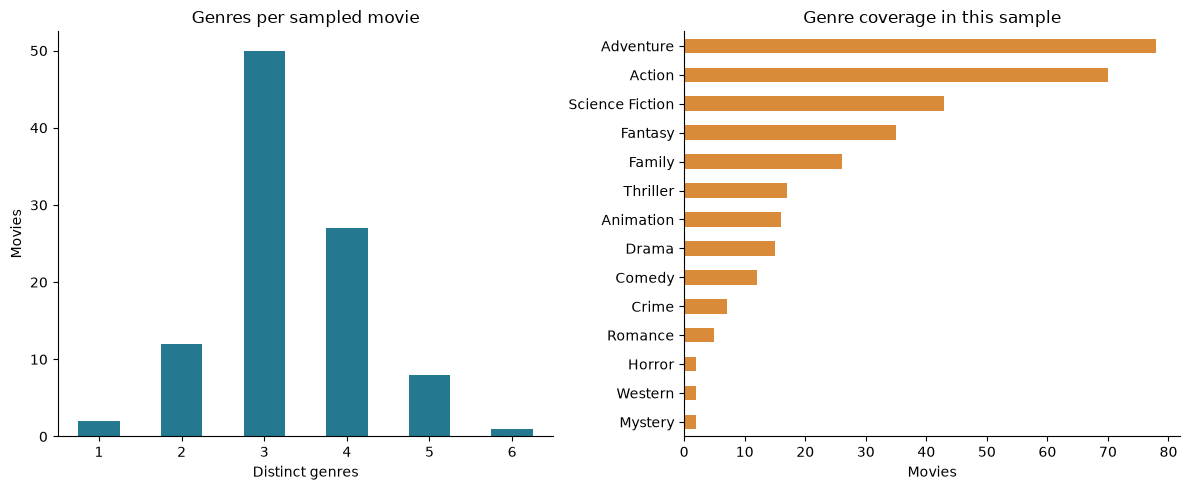

In [6]:
genre_links = flat['genres'][['movie_id', 'id']].drop_duplicates()
genres_per_movie = genre_links.groupby('movie_id').id.nunique().reindex(movies.id, fill_value=0)
genre_freq = flat['genres'].groupby('name').movie_id.nunique().sort_values()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
genres_per_movie.value_counts().sort_index().plot.bar(ax=axes[0], color='#24788f', rot=0)
axes[0].set(title='Genres per sampled movie', xlabel='Distinct genres', ylabel='Movies')
genre_freq.plot.barh(ax=axes[1], color='#d98b39')
axes[1].set(title='Genre coverage in this sample', xlabel='Movies', ylabel='')
plt.tight_layout(); plt.show()

**Decision:** use repeated movie→genre edges. A movie can have multiple genres.
The proposed kg:Genre can specialize schema:DefinedTerm; retain schema:genre
as the predicate to stay close to the reference. This plot supports the
many-to-many design, but sample counts cannot establish universal cardinality.

## 5. People and movie-specific credits

For an initial reference-like graph, retain ten lowest-order cast entries per
movie and all directors. The rest of the raw crew helps us see potential
extensions. We explore those entries but do not automatically add them to scope.

For an extended model, use a CrewCredit node with person, job, and department;
direct movie→director edges can coexist for convenient queries. A shared person
must keep the same URI whether appearing in cast or crew.

In [7]:
cast = flat['cast'].copy()
crew = flat['crew'].copy()
cast['order_numeric'] = pd.to_numeric(cast['order'], errors='coerce')
kept_cast = cast.sort_values(['movie_id', 'order_numeric'], kind='stable').groupby('movie_id').head(10)
directors = crew.loc[crew.job.eq('Director')]
people_credits = pd.concat([cast[['movie_id', 'id', 'name']],
                           crew[['movie_id', 'id', 'name']]], ignore_index=True)
person_movie_counts = people_credits.groupby('id').movie_id.nunique().sort_values(ascending=False)
person_id = person_movie_counts.index[0]
display(people_credits.loc[people_credits.id.eq(person_id)].drop_duplicates().head(10))
display(crew.loc[crew.id.eq(person_id), ['movie_id', 'id', 'name', 'job', 'department']].head(10))
display(crew.job.value_counts().head(12).rename('sample credit rows').to_frame())
print('Full sampled cast rows:', len(cast), '| First-ten retained:', len(kept_cast))
print('Director credits:', len(directors))
print('Movie-specific credit IDs duplicated:',
      int(pd.concat([cast[['movie_id', 'credit_id']], crew[['movie_id', 'credit_id']]]).duplicated().sum()))
director_counts = directors.groupby('movie_id').id.nunique().reindex(movies.id, fill_value=0)
print('Sampled movies with multiple directors:', int(director_counts.gt(1).sum()))

,movie_id,id,name
406,559,7624,Stan Lee
563,99861,7624,Stan Lee
1027,24428,7624,Stan Lee
1236,1930,7624,Stan Lee
1568,271110,7624,Stan Lee
1752,558,7624,Stan Lee
1865,68721,7624,Stan Lee
1987,36668,7624,Stan Lee
2270,102382,7624,Stan Lee
3253,246655,7624,Stan Lee


,movie_id,id,name,job,department
693,559,7624,Stan Lee,Author,Writing
694,559,7624,Stan Lee,Executive Producer,Production
829,99861,7624,Stan Lee,Executive Producer,Production
830,99861,7624,Stan Lee,Characters,Writing
1274,24428,7624,Stan Lee,Comic Book,Writing
1275,24428,7624,Stan Lee,Executive Producer,Production
1605,1930,7624,Stan Lee,Executive Producer,Production
1606,1930,7624,Stan Lee,Characters,Writing
1972,271110,7624,Stan Lee,Executive Producer,Production
2679,558,7624,Stan Lee,Executive Producer,Production


,sample credit rows
job,
Art Direction,276
Producer,274
Executive Producer,268
Casting,191
Screenplay,186
Visual Effects Supervisor,156
Stunts,148
Set Costumer,145
Editor,142


Full sampled cast rows: 4888 | First-ten retained: 1000
Director credits: 111
Movie-specific credit IDs duplicated: 0
Sampled movies with multiple directors: 10


~~~text
Movie → actor → Person
Movie → actor → Role → actor → Person
                   → characterName → text
                   → position → integer

Optional extension:
Movie → hasCrewCredit → CrewCredit → person → Person
                                   → job → text
                                   → department → text
~~~

Cast character and order belong to Role. Crew job/department belong to
CrewCredit if we extend beyond directors. A named credit URI can use a checked
source credit_id plus movie ID; repeated or conflicting IDs need validation.
Alternatively use blank nodes to follow the reference's acting-role design.

## 6. Values, missingness, and checks before OWL

We retain raw strings and convert an analysis copy. Blank, malformed, negative,
and zero values deserve different treatment. In particular order 0 is valid;
budget/revenue/runtime 0 can be a placeholder rather than a known zero.
We will choose a documented cleaning policy before transformation.

In [8]:
numeric_fields = ['runtime', 'vote_average', 'vote_count', 'budget', 'revenue', 'popularity']
numeric = movies[numeric_fields].apply(pd.to_numeric, errors='coerce')
quality = []
for field in numeric_fields:
    quality.append({'field': field,
                    'blank': int(movies[field].str.strip().eq('').sum()),
                    'nonempty unparseable': int((movies[field].ne('') & numeric[field].isna()).sum()),
                    'negative': int(numeric[field].lt(0).sum()),
                    'zero': int(numeric[field].eq(0).sum()),
                    'noninteger': int((numeric[field].notna() & numeric[field].mod(1).ne(0)).sum())
                    if field in ['runtime', 'vote_count', 'budget', 'revenue'] else 'allowed decimals'})
display(pd.DataFrame(quality))
dates = pd.to_datetime(movies.release_date, format='%Y-%m-%d', errors='coerce')
print('Nonempty invalid dates:', int((movies.release_date.ne('') & dates.isna()).sum()))
print('Ratings outside 0–10:', int((numeric.vote_average.notna() &
                                  ~numeric.vote_average.between(0, 10)).sum()))
print('Cast orders negative or malformed:', int((cast.order_numeric.isna() |
                                                cast.order_numeric.lt(0) |
                                                cast.order_numeric.mod(1).ne(0)).sum()))

,field,blank,nonempty unparseable,negative,zero,noninteger
0,runtime,0,0,0,0,0
1,vote_average,0,0,0,0,allowed decimals
2,vote_count,0,0,0,0,0
3,budget,0,0,0,0,0
4,revenue,0,0,0,1,0
5,popularity,0,0,0,0,allowed decimals


Nonempty invalid dates: 0
Ratings outside 0–10: 0
Cast orders negative or malformed: 0


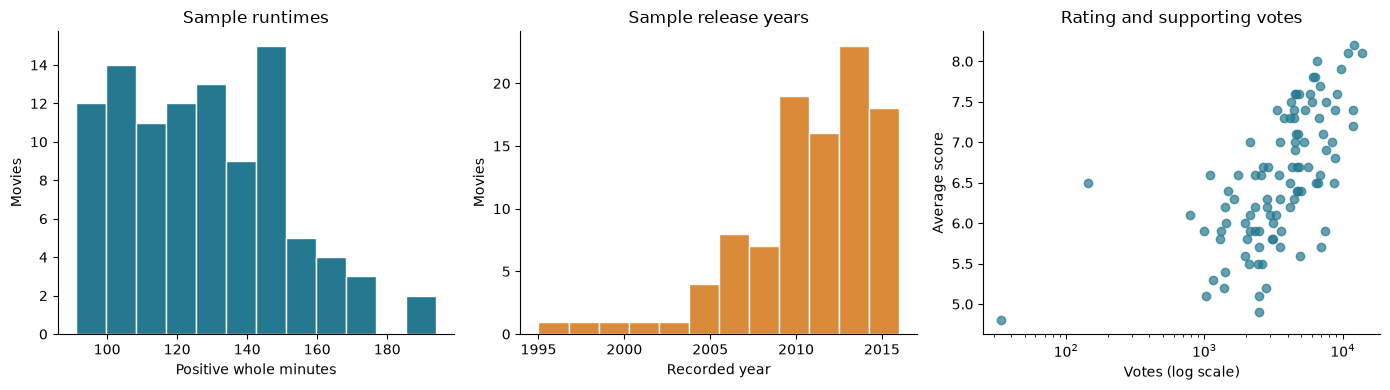

In [9]:
valid_ratings = (numeric.vote_count.gt(0) & numeric.vote_count.mod(1).eq(0) &
                 numeric.vote_average.between(0, 10))
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
runtime = numeric.runtime.where(numeric.runtime.gt(0) & numeric.runtime.mod(1).eq(0)).dropna()
axes[0].hist(runtime, bins=12, color='#24788f', edgecolor='white')
axes[0].set(title='Sample runtimes', xlabel='Positive whole minutes', ylabel='Movies')
axes[1].hist(dates.dt.year.dropna(), bins=12, color='#d98b39', edgecolor='white')
axes[1].set(title='Sample release years', xlabel='Recorded year', ylabel='Movies')
axes[2].scatter(numeric.loc[valid_ratings, 'vote_count'],
                numeric.loc[valid_ratings, 'vote_average'], alpha=.7, color='#24788f')
axes[2].set_xscale('log')
axes[2].set(title='Rating and supporting votes', xlabel='Votes (log scale)', ylabel='Average score')
plt.tight_layout(); plt.show()

**Decisions:** date → xsd:date; minutes → xsd:duration such as PT162M; score →
xsd:decimal; vote count and cast order → xsd:integer. IDs remain identifiers,
even when they look numeric. One rating node groups score and count. A missing
score is unknown; zero votes cannot support a meaningful observed average.
The sample's earliest year and shortest runtime are not universal Movie limits.

### Original versus spoken language

Keep original_language → kg:originalLanguage separate from spoken_languages →
schema:inLanguage, so our spoken-language question has a precise meaning.
Some original-language codes may lack a named entry in the sampled spoken
lists. Preserve the code; fetch a label later or leave it unknown.

In [10]:
spoken_by_movie = flat['spoken_languages'].groupby('movie_id').iso_639_1.agg(set)
spoken_counts = movies.id.map(lambda mid: len(spoken_by_movie.get(mid, set())))
original_only_codes = set(movies.original_language) - {''} - set(flat['spoken_languages'].iso_639_1)
print('Movies with several spoken languages:', int(spoken_counts.gt(1).sum()))
print('Original-language codes without sampled labels:', sorted(original_only_codes))
print('Company internal fields:', list(flat['production_companies'].columns))
print('Company origin_country available:', 'origin_country' in flat['production_companies'].columns)

Movies with several spoken languages: 30
Original-language codes without sampled labels: []
Company internal fields: ['movie_id', 'name', 'id']
Company origin_country available: False


## 7. Which constraints should we define?

| Proposed statement | Use | Important distinction |
|---|---|---|
| Movie and Person have distinct meanings | OWL disjointness, if adopted | An actor and director can be the same Person |
| Movie is a CreativeWork | OWL subclass | Inference, not a source cleaning rule |
| director links Movie to Person | OWL domain/range | Using the property infers types |
| directedMovie reverses director | OWL inverse | Adds a useful inferred relationship |
| A Role connects to one Person in our design | Qualified cardinality + explicit data check | OWL alone does not flag every missing field |
| Movie can have multiple genres, directors, languages | Permit repeated edges | Do not declare these functional |
| IDs and join targets are valid | Python or later SHACL checks | Database-style quality rule |
| A rating has at most one value/count in this snapshot | Snapshot modeling restriction | Historical measurements require a different model |
| Counts/orders are nonnegative; score is 0–10 | Numeric checks or SHACL | Validate before RDF generation |
| Company-country chain derives a movie shortcut | Deferred OWL axiom | Need company origin data first |

**Open world:** absent information is unknown. A minimum-name restriction
does not enforce a populated CSV cell. **Functional property:** two object
URIs can be inferred equal instead of rejected. **Domain/range:** these infer
types; attaching a property to the wrong subject may cause unintended typing.

Do not use Movie-only domain for a generic name/identifier property used on
people and companies. The reference's actor predicate appears on both Movie
and Role, which also needs appropriate typing. See the
[OWL 2 Primer](https://www.w3.org/TR/owl2-primer/) for these semantics.

## 8. What can we add without losing the reference's basic structure?

| Addition | Class/property choice | New question it enables | Cost or limitation |
|---|---|---|---|
| Keywords | kg:Keyword subclass of schema:DefinedTerm; kg:hasKeyword | Which films share descriptive themes? | Labels are source terms, not proven plot facts |
| Original title / tagline | String properties on Movie | How do display and original titles differ? | No new classes needed |
| Producer/writer/director roles | CrewCredit with Person, job and department | Who collaborated across different crew jobs? | Movie-specific credits are more complex |
| Budget/revenue | Numeric properties on Movie | Which films have recorded revenue above budget? | Zero/missing values, currency and provenance; not profit |
| Status | Literal kg:status initially | Which records have a particular source status? | A controlled term vocabulary is optional later |
| Homepage | Link property or rdfs:seeAlso | Where can a user find the source-listed homepage? | URL availability; does not mean owl:sameAs |
| Popularity | Snapshot metric literal | How does source popularity vary? | Changing metric; no observation timestamp in file |

**Recommended first extension: keywords.** It uses the same entity-plus-link
pattern as genres and does not change existing actor/director/rating queries.
Original title and tagline are also small additions. CrewCredit is a useful
second extension once you understand Role nodes. Budget/revenue need more
careful interpretation, so keep them optional.

Adding a raw field does not automatically make it an OWL class. A movie's
status can stay a literal; keyword entities are useful because they recur and
connect movies. No extension is implemented as an ontology yet.

In [11]:
keyword_frequency = flat['keywords'].groupby(['id', 'name']).movie_id.nunique().rename('sample movies')
display(keyword_frequency.sort_values(ascending=False).head(12).reset_index())
display(movies[['id', 'title', 'original_title', 'tagline', 'status']].head(5))
print('These previews illustrate available extensions; they do not broaden the agreed core automatically.')

,id,name,sample movies
0,209714,3d,24
1,179430,aftercreditsstinger,19
2,179431,duringcreditsstinger,19
3,9715,superhero,17
4,9717,based on comic book,15
5,8828,marvel comic,15
6,9663,sequel,13
7,156395,imax,11
8,4565,dystopia,9
9,9951,alien,8


,id,title,original_title,tagline,status
0,19995,Avatar,Avatar,Enter the World of Pandora.,Released
1,285,Pirates of the Caribbean: At World's End,Pirates of the Caribbean: At World's End,"At the end of the world, the adventure begins.",Released
2,206647,Spectre,Spectre,A Plan No One Escapes,Released
3,49026,The Dark Knight Rises,The Dark Knight Rises,The Legend Ends,Released
4,49529,John Carter,John Carter,"Lost in our world, found in another.",Released


These previews illustrate available extensions; they do not broaden the agreed core automatically.


## 9. Reproduce the normalized table pattern in memory

For a list of shared entities: one lookup table stores ID/label, and a link
table stores movie ID/entity ID. Deduplicate exact rows, but inspect conflicting
labels for the same ID before selecting one. The next cell demonstrates genres
and optional keywords across our sampled movies. It writes no files.

In [12]:
def split_terms(entries):
    labels_per_id = entries.groupby('id').name.nunique()
    conflicting = labels_per_id[labels_per_id.gt(1)]
    if len(conflicting):
        raise ValueError(f'Resolve conflicting labels for IDs: {list(conflicting.index[:10])}')
    lookup = entries[['id', 'name']].drop_duplicates()
    links = entries[['movie_id', 'id']].drop_duplicates()
    return lookup, links
genre_table, movie_genres = split_terms(flat['genres'])
movie_genres = movie_genres.rename(columns={'id': 'genre_id'})
keyword_table, movie_keywords = split_terms(flat['keywords'])
movie_keywords = movie_keywords.rename(columns={'id': 'keyword_id'})
display(Markdown('**Future genres.csv and movie_genres.csv**'))
display(genre_table.head(5)); display(movie_genres.head(5))
display(Markdown('**Optional keywords.csv and movie_keywords.csv**'))
display(keyword_table.head(5)); display(movie_keywords.head(5))

**Future genres.csv and movie_genres.csv**

,id,name
0,28,Action
1,12,Adventure
2,14,Fantasy
3,878,Science Fiction
9,80,Crime


,movie_id,genre_id
0,19995,28
1,19995,12
2,19995,14
3,19995,878
4,285,12


**Optional keywords.csv and movie_keywords.csv**

,id,name
0,1463,culture clash
1,2964,future
2,3386,space war
3,3388,space colony
4,3679,society


,movie_id,keyword_id
0,19995,1463
1,19995,2964
2,19995,3386
3,19995,3388
4,19995,3679


### Future CSV layout and the differences from the reference

| Future table | Fields / source | Reference compatibility |
|---|---|---|
| movies.csv | id, title, overview, original_language, release_date, runtime, vote_average, vote_count | IMDb ID is unavailable; document omission/enrichment |
| genres.csv | genres.id → id, genres.name → name | Same layout |
| movie_genres.csv | movie_id, genre_id | Same layout |
| companies.csv | production_companies.id/name | origin_country unavailable; leave unknown or enrich |
| movie_companies.csv | movie_id, company_id | Same layout |
| countries.csv | iso_3166_1 → country_code, name | From movie production countries |
| movie_countries.csv | movie_id, country_code | Same layout |
| languages.csv | iso_639_1 → language_code, name | Also cover original-language codes without inventing names |
| movie_languages.csv | movie_id, language_code | Spoken-language membership |
| cast.csv | movie_id, person_id, person_name, character, order | Keep first ten; optionally retain credit_id |
| crew.csv | movie_id, person_id, person_name, job | Directors only for core |
| Optional keywords + movie_keywords | keyword IDs/names and relationship pairs | Small extension |
| Optional crew_credits.csv | movie_id, person_id, job, department, credit_id | Extension preserving movie-specific jobs |

IDs from nested JSON arrive as numbers; normalize them to the same string form
used by movie IDs before export. A separate people.csv is optional: the reference
derives people from credits. Future classes need not correspond one-to-one to
CSV tables: Role and AggregateRating can be created during RDF transformation.

## 10. Observation → modeling decision

This table closes the lesson with decisions grounded in the sampled data.
It does not claim that all source records or future ontology axioms have been
validated. The next stage chooses the final core/extensions and writes OWL.

In [13]:
decisions = [
 (f'{len(movies)} movie rows and {len(credits)} credit rows sampled', 'Join by id/movie_id', 'Counts describe only this bounded sample'),
 ('Nested lists contain shared IDs and labels', 'Create shared Genre/Organization/Country/Language instances', 'Do not turn every field into a class'),
 (f'{int(genres_per_movie.gt(1).sum())} sampled movies have multiple genres', 'Allow multiple schema:genre edges', 'No exactly-one genre rule'),
 (f'{int(person_movie_counts.gt(1).sum())} people recur across sampled films', 'Reuse Person URIs', 'Names are labels'),
 ('Cast character/order and crew job/department are participation fields', 'Use Role; optionally CrewCredit', 'Do not store movie-specific jobs globally on Person'),
 (f'{int(director_counts.gt(1).sum())} sampled films have several directors', 'Allow multiple director edges', 'Sample observations do not define universal cardinality'),
 ('Runtime/date/rating fields are scalar text in CSV', 'Validate and create typed literals', 'IDs that look numeric are still identifiers'),
 ('Average and count describe one summary', 'Group them in AggregateRating', 'Snapshot, not rating history'),
 ('Original and spoken language fields are separate', 'Keep kg:originalLanguage separate from schema:inLanguage', 'Cover missing language labels'),
 ('No imdb_id or company origin country supplied', 'Plan evidence-based enrichment if needed', 'Do not infer company country from movie country'),
 ('Keywords recur and have source IDs', 'Optional Keyword instances and hasKeyword edges', 'Keywords are annotations, not proof of plot facts')]
display(pd.DataFrame(decisions, columns=['Observation', 'Proposed decision', 'Limit / caution']))

,Observation,Proposed decision,Limit / caution
0,100 movie rows and 100 credit rows sampled,Join by id/movie_id,Counts describe only this bounded sample
1,Nested lists contain shared IDs and labels,Create shared Genre/Organization/Country/Language instances,Do not turn every field into a class
2,98 sampled movies have multiple genres,Allow multiple schema:genre edges,No exactly-one genre rule
3,1632 people recur across sampled films,Reuse Person URIs,Names are labels
4,Cast character/order and crew job/department are participatio...,Use Role; optionally CrewCredit,Do not store movie-specific jobs globally on Person
5,10 sampled films have several directors,Allow multiple director edges,Sample observations do not define universal cardinality
6,Runtime/date/rating fields are scalar text in CSV,Validate and create typed literals,IDs that look numeric are still identifiers
7,Average and count describe one summary,Group them in AggregateRating,"Snapshot, not rating history"
8,Original and spoken language fields are separate,Keep kg:originalLanguage separate from schema:inLanguage,Cover missing language labels
9,No imdb_id or company origin country supplied,Plan evidence-based enrichment if needed,Do not infer company country from movie country


### Before writing the ontology, try explaining these

1. Why is a film an instance, while Movie is a class?
2. Why is Action a Genre instance rather than a new Movie class?
3. Why do character and crew job belong to participation in a movie?
4. Why is missing IMDb ID a data limitation rather than an ontology failure?
5. What extra evidence is needed for the company-country property chain?
6. Which extension would you choose first, and which question would it answer?

Suggested answers: categories group individuals; genre terms are linked
annotations; participation attributes depend on the movie; an ontology cannot
invent source identifiers; company-specific origin data is needed; keywords
are a small extension for shared-theme queries.